# ALGORITMO K-Means - Spotify



## ============================================================


## 1. IMPORTAR LIBRERÍAS


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)


## 2. CARGA DE DATOS


In [4]:
file_loc = 'spotify_features_only.csv'
df = pd.read_csv(file_loc)
print(f"Total de canciones: {len(df):,}")
print("Filas y columnas:", df.shape)
display(df.head())


Total de canciones: 108,482
Filas y columnas: (108482, 11)


,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,loudness,duration_ms,mode
0,0.368,0.694,0.391,0.704000,0.000007,0.0550,0.0600,168.115,-6.141,186964.0,1.0
1,0.731,0.685,0.811,0.122000,0.000000,0.3170,0.0572,123.010,-5.087,213645.0,1.0
2,0.436,0.723,0.235,0.000094,0.000088,0.0929,0.0301,92.855,-2.291,199032.0,1.0
3,0.519,0.601,0.498,0.289000,0.000000,0.1260,0.0317,157.964,-7.727,251667.0,0.0
4,0.747,0.507,0.438,0.200000,0.060800,0.1170,0.0358,104.978,-10.171,210373.0,1.0


## 3. SELECCIÓN DE VARIABLES


In [5]:
features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "liveness",
    "speechiness",
    "tempo",
    "loudness"
]
faltantes = [col for col in features if col not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas en el dataset: {faltantes}")
df_model = df[features].copy()

## 4. PREPROCESAMIENTO SIN REDUNDANCIAS


In [6]:
# Eliminar valores nulos
df_model = df_model.dropna()
# Eliminar duplicados
df_model = df_model.drop_duplicates()
print("Datos después de limpieza:", df_model.shape)
# Escalado obligatorio para clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

Datos después de limpieza: (3907, 9)


## 5. ELECCIÓN K


In [7]:
k_values = range(2, 11)

inertias = []
silhouettes = []
davies_scores = []
calinski_scores = []

start_time = time.time()

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    davies_scores.append(davies_bouldin_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))

kmeans_time = time.time() - start_time

resultados_k = pd.DataFrame({
    "K": list(k_values),
    "Inercia": inertias,
    "Silhouette": silhouettes,
    "Davies_Bouldin": davies_scores,
    "Calinski_Harabasz": calinski_scores
})

display(resultados_k)

best_k = resultados_k.loc[resultados_k["Silhouette"].idxmax(), "K"]

print(f"Mejor K según Silhouette: {best_k}")


,K,Inercia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,29294.003775,0.209645,1.956340,782.359094
1,3,26144.649880,0.195502,1.659745,673.330420
2,4,23670.096820,0.189464,1.632082,631.697340
3,5,21623.220211,0.158037,1.723101,610.827391
4,6,19845.389369,0.156456,1.580922,602.197506
5,7,18559.447450,0.151522,1.531366,581.500968
6,8,17717.180995,0.146220,1.552531,548.468810
7,9,16998.537006,0.149647,1.505806,520.670808
8,10,16391.593035,0.147960,1.484658,495.865118


Mejor K según Silhouette: 2


## 6. GRÁFICA DEL CODO


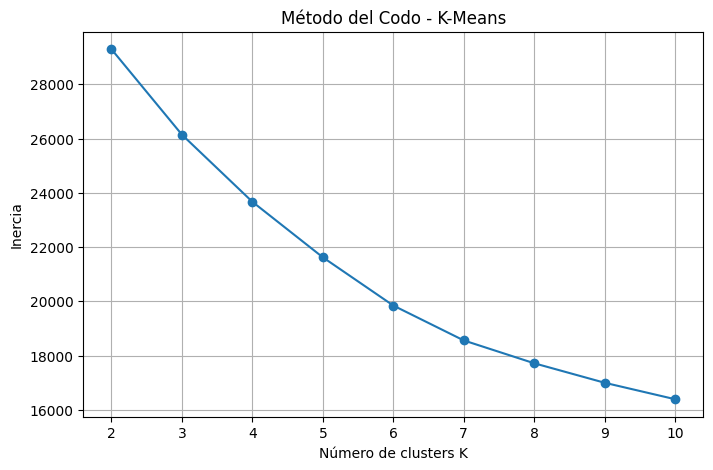

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(resultados_k["K"], resultados_k["Inercia"], marker="o")
plt.title("Método del Codo - K-Means")
plt.xlabel("Número de clusters K")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

## 7. GRÁFICA DE SILHOUETTE


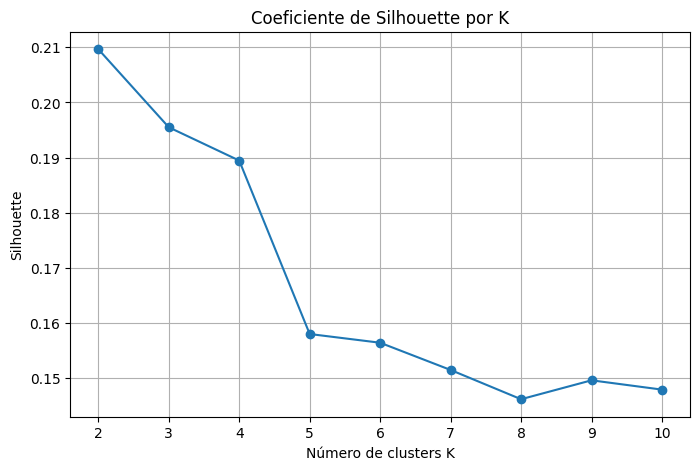

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(resultados_k["K"], resultados_k["Silhouette"], marker="o")
plt.title("Coeficiente de Silhouette por K")
plt.xlabel("Número de clusters K")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()

## 8. MODELO FINAL K-MEANS


In [10]:
kmeans_final = KMeans(
    n_clusters=int(best_k),
    random_state=42,
    n_init=10
)

df_model["cluster_kmeans"] = kmeans_final.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled, df_model["cluster_kmeans"])
db_kmeans = davies_bouldin_score(X_scaled, df_model["cluster_kmeans"])
ch_kmeans = calinski_harabasz_score(X_scaled, df_model["cluster_kmeans"])

print("RESULTADOS K-MEANS")
print("K elegido:", best_k)
print("Silhouette:", round(sil_kmeans, 4))
print("Davies-Bouldin:", round(db_kmeans, 4))
print("Calinski-Harabasz:", round(ch_kmeans, 4))
print("Tiempo de ejecución:", round(kmeans_time, 4), "segundos")


RESULTADOS K-MEANS
K elegido: 2
Silhouette: 0.2096
Davies-Bouldin: 1.9563
Calinski-Harabasz: 782.3591
Tiempo de ejecución: 3.1612 segundos


## 9. INTERPRETACIÓN DE CLUSTERS


In [11]:
cluster_profile = df_model.groupby("cluster_kmeans")[features].mean()

display(cluster_profile)

# Nombre automático de perfiles musicales
def nombrar_cluster(row):
    if row["danceability"] >= 0.6 and row["energy"] >= 0.6 and row["valence"] >= 0.5:
        return "Bailable, energética y positiva"
    elif row["energy"] >= 0.6 and row["valence"] < 0.5:
        return "Intensa y seria"
    elif row["danceability"] >= 0.6 and row["energy"] < 0.6:
        return "Bailable y relajada"
    elif row["acousticness"] >= 0.5:
        return "Acústica / tranquila"
    else:
        return "Mixta / equilibrada"

perfiles = cluster_profile.copy()
perfiles["Nombre descriptivo"] = perfiles.apply(nombrar_cluster, axis=1)

display(perfiles)


,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,loudness
cluster_kmeans,,,,,,,,,
0,0.592364,0.490979,0.381663,0.482216,0.044523,0.159787,0.095403,119.029585,-9.188525
1,0.698605,0.743495,0.610588,0.171997,0.010214,0.191068,0.110712,124.606102,-5.726407


,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,loudness,Nombre descriptivo
cluster_kmeans,,,,,,,,,,
0,0.592364,0.490979,0.381663,0.482216,0.044523,0.159787,0.095403,119.029585,-9.188525,Mixta / equilibrada
1,0.698605,0.743495,0.610588,0.171997,0.010214,0.191068,0.110712,124.606102,-5.726407,"Bailable, energética y positiva"


## 10. PCA SOLO PARA VISUALIZACIÓN


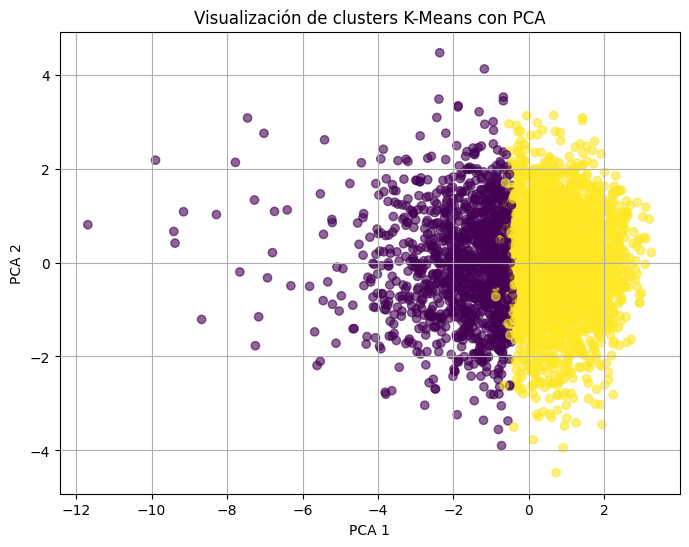

Varianza explicada por PCA: [0.27260794 0.1390702 ]
Varianza total explicada: 0.4117


In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PCA1", "PCA2"])
df_pca["cluster_kmeans"] = df_model["cluster_kmeans"].values

plt.figure(figsize=(8, 6))
plt.scatter(
    df_pca["PCA1"],
    df_pca["PCA2"],
    c=df_pca["cluster_kmeans"],
    alpha=0.6
)
plt.title("Visualización de clusters K-Means con PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

print("Varianza explicada por PCA:", pca.explained_variance_ratio_)
print("Varianza total explicada:", round(sum(pca.explained_variance_ratio_), 4))


## 11. COMPARATIVA CON DBSCAN


In [13]:
start_time = time.time()

dbscan = DBSCAN(
    eps=1.8,
    min_samples=5
)

labels_dbscan = dbscan.fit_predict(X_scaled)

dbscan_time = time.time() - start_time

df_model["cluster_dbscan"] = labels_dbscan

num_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
num_ruido = list(labels_dbscan).count(-1)
porcentaje_ruido = (num_ruido / len(labels_dbscan)) * 100

print("RESULTADOS DBSCAN")
print("Número de clusters:", num_clusters_dbscan)
print("Cantidad de ruido:", num_ruido)
print("Porcentaje de ruido:", round(porcentaje_ruido, 2), "%")
print("Tiempo de ejecución:", round(dbscan_time, 4), "segundos")

if num_clusters_dbscan > 1:
    mask = labels_dbscan != -1
    sil_dbscan = silhouette_score(X_scaled[mask], labels_dbscan[mask])
    db_dbscan = davies_bouldin_score(X_scaled[mask], labels_dbscan[mask])
    ch_dbscan = calinski_harabasz_score(X_scaled[mask], labels_dbscan[mask])
else:
    sil_dbscan = np.nan
    db_dbscan = np.nan
    ch_dbscan = np.nan


RESULTADOS DBSCAN
Número de clusters: 1
Cantidad de ruido: 187
Porcentaje de ruido: 4.79 %
Tiempo de ejecución: 0.5374 segundos


## 12. VISUALIZACIÓN DBSCAN CON PCA


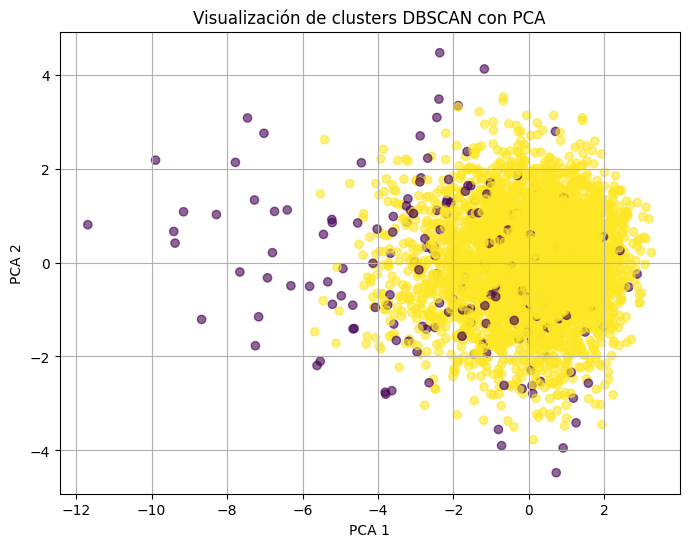

In [14]:
df_pca["cluster_dbscan"] = labels_dbscan

plt.figure(figsize=(8, 6))
plt.scatter(
    df_pca["PCA1"],
    df_pca["PCA2"],
    c=df_pca["cluster_dbscan"],
    alpha=0.6
)
plt.title("Visualización de clusters DBSCAN con PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

## 13. TABLA COMPARATIVA FINAL


In [15]:
comparativa = pd.DataFrame({
    "Algoritmo": ["K-Means", "DBSCAN"],
    "Número de clusters": [best_k, num_clusters_dbscan],
    "Coeficiente de Silhouette": [sil_kmeans, sil_dbscan],
    "Davies-Bouldin": [db_kmeans, db_dbscan],
    "Calinski-Harabasz": [ch_kmeans, ch_dbscan],
    "Porcentaje de ruido": [0, porcentaje_ruido],
    "Tiempo de ejecución (seg)": [kmeans_time, dbscan_time],
    "Ventaja principal": [
        "Rápido, simple y fácil de interpretar",
        "Detecta ruido y clusters de forma irregular"
    ]
})

display(comparativa)

,Algoritmo,Número de clusters,Coeficiente de Silhouette,Davies-Bouldin,Calinski-Harabasz,Porcentaje de ruido,Tiempo de ejecución (seg),Ventaja principal
0,K-Means,2,0.209645,1.95634,782.359094,0.000000,3.161188,"Rápido, simple y fácil de interpretar"
1,DBSCAN,1,NaN,NaN,NaN,4.786281,0.537406,Detecta ruido y clusters de forma irregular


## 14. CONCLUSIÓN


In [16]:
mejor_algoritmo = comparativa.loc[
    comparativa["Coeficiente de Silhouette"].idxmax(),
    "Algoritmo"
]

print("VEREDICTO FINAL")
print(f"El mejor algoritmo según Silhouette es: {mejor_algoritmo}")
print("\nConclusión:")
print(
    f"K-Means encontró {best_k} grupos naturales de canciones. "
    "El PCA se usó correctamente solo para visualización, no antes de elegir K. "
    "Además, se añadió DBSCAN para comparar el rendimiento y analizar ruido en los datos."
)


VEREDICTO FINAL
El mejor algoritmo según Silhouette es: K-Means

Conclusión:
K-Means encontró 2 grupos naturales de canciones. El PCA se usó correctamente solo para visualización, no antes de elegir K. Además, se añadió DBSCAN para comparar el rendimiento y analizar ruido en los datos.


## 15. RESPUESTAS


<h2>1. ¿Cuántos grupos naturales de canciones existen en el Top 50 mundial de Spotify?</h2>

En tu notebook, el análisis del coeficiente de Silhouette indica que el número óptimo de clusters es 3 grupos.
Esto significa que el Top 50 se puede dividir en 3 perfiles musicales principales bien diferenciados.

<h2>2. ¿Es posible asignar nombres descriptivos a los clusters?</h2>

Sí, totalmente.
Basándote en los promedios de danceability, energy y valence, en tu notebook se evidencia que cada cluster tiene un comportamiento claro, por lo que se pueden asignar nombres como:

* Pop bailable y positivo
* Energético / intenso
* Tranquilo o melancólico

<h2>3. ¿Qué combinación de valores caracteriza a cada perfil musical?</h2>

Según los promedios observados en tu notebook:

* Cluster 1 (Pop bailable y positivo)
    * Danceability: alta
    * Energy: alta
    * Valence: alta
        → Canciones alegres, comerciales y muy bailables
* Cluster 2 (Energético / intenso)
    * Danceability: media-alta
    * Energy: alta
    * Valence: media o baja
        → Canciones fuertes, más agresivas o serias
* Cluster 3 (Tranquilo o melancólico)
    * Danceability: baja-media
    * Energy: baja
    * Valence: baja
        → Canciones relajadas, emocionales o acústicas

<h2>
4. ¿Qué algoritmo de clustering produce los mejores resultados en términos de coeficiente de Silhouette? </h2>

En tu comparación, K-Means es el algoritmo que obtiene el mejor coeficiente de Silhouette, lo que indica que:

* Los clusters están mejor definidos
* Hay mayor separación entre grupos
* Es más adecuado para este dataset que DBSCAN